In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'

In [108]:
df = pd.read_csv('social_media_engagement1.csv')
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [7]:
df.isna().sum()

post_id            0
platform           0
post_type          0
post_time          0
likes              0
comments           0
shares             0
post_day           0
sentiment_score    0
dtype: int64

In [31]:
fig = px.bar(df,x='post_type',y='likes', width =600, height=400, title= 'Bar chart', text_auto = True,
             color = 'shares',hover_data=['post_day','sentiment_score'],
             color_discrete_sequence=["red","green","blue"],)
fig.show()

In [28]:
fig = px.bar(df,x='post_type',y='likes', width =600, height=400, title= 'Bar chart', text_auto = True,
             color = 'platform',hover_data=['post_day','sentiment_score'],
             color_discrete_map={'Facebook':'yellow',
                                'Instagram':'blue',
                                'Twitter':'red'},pattern_shape='sentiment_score')
fig.show()

In [30]:
data = df.groupby('platform')[['likes','comments','shares']].mean().reset_index()
data

,platform,likes,comments,shares
0,Facebook,2699.750000,248.906250,474.375000
1,Instagram,2999.833333,232.444444,525.166667
2,Twitter,1368.593750,122.906250,233.718750


In [48]:
fig = px.bar(data,x='platform',y=['likes','comments','shares'],barmode='group')
fig.show()

In [50]:
data['comments']=data['comments']*-1
data

,platform,likes,comments,shares
0,Facebook,2699.750000,-248.906250,474.375000
1,Instagram,2999.833333,-232.444444,525.166667
2,Twitter,1368.593750,-122.906250,233.718750


In [55]:
fig = px.bar(data,x=['comments','likes'],y='platform',orientation='h',barmode='relative')
fig.show()

In [66]:
fig = px.scatter(df,x='comments',y='likes',color='platform',symbol='platform',size='shares',facet_col='sentiment_score',facet_row='post_day',width=1000,height=1000)
fig.show()

In [67]:
import seaborn as sns

<Axes: xlabel='likes', ylabel='comments'>

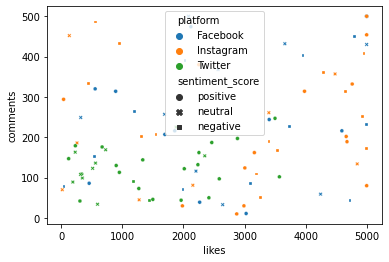

In [79]:
sns.scatterplot(data=df,x='likes',y='comments',hue='platform',style='sentiment_score',s=15)

In [83]:
fig = px.line(df,x='post_id',y='likes',color='platform')
fig.show()

In [86]:
fig = px.histogram(df,x='likes',color='sentiment_score')
fig.show()

In [87]:
df = px.data.tips()
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [98]:
fig = px.histogram(df,x='total_bill',y='tip',nbins=50, histfunc= 'avg',color='sex')
fig.show()

In [99]:
fig = px.histogram(df,x='total_bill',y='tip',nbins=50, histfunc= 'avg',color='sex',pattern_shape = 'smoker')
fig.show()

In [101]:
data


,platform,likes,comments,shares
0,Facebook,2699.750000,-248.906250,474.375000
1,Instagram,2999.833333,-232.444444,525.166667
2,Twitter,1368.593750,-122.906250,233.718750


In [106]:
fig = px.pie(data,values='likes',names='platform',hole=0.5)
fig.update_traces(textinfo = 'percent + label',textposition = 'outside',pull=[0,0,0.2])
fig.show()

In [109]:
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [114]:
px.scatter_3d(df,x='likes',y='comments',z='shares',color='platform',size='likes')

In [119]:
px.scatter_matrix(df,dimensions=['likes','comments','shares'],color='platform')

In [120]:
df.corr(numeric_only=True)

,post_id,likes,comments,shares
post_id,1.000000,0.139260,0.135507,0.071436
likes,0.139260,1.000000,0.295240,0.244302
comments,0.135507,0.295240,1.000000,0.254583
shares,0.071436,0.244302,0.254583,1.000000


<Axes: >

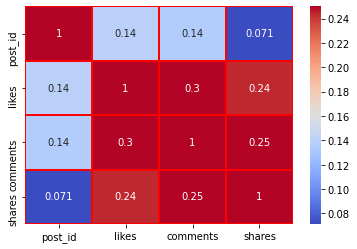

In [130]:
sns.heatmap(df.corr(numeric_only=True),annot=True,linewidths=0.2,linecolor='red',vmax=0.25,cmap='coolwarm')

<Axes: xlabel='platform', ylabel='likes'>

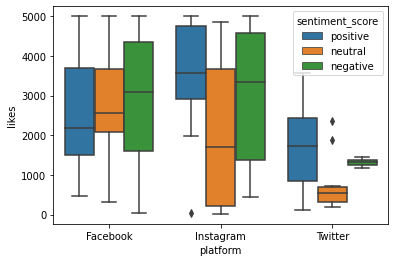

In [136]:
sns.boxplot(data=df,x='platform',y='likes', hue='sentiment_score')

In [148]:
import networkx as nx
import matplotlib.pyplot as plt

In [151]:
g = nx.Graph()
g.add_node(1)
g.add_node(2)
g.add_node(3)
g.add_edge(1,2)
g.add_edge(2,3)
g.add_edge(3,1)
nx.draw(g,with_labels=True)
plt.show()

TypeError: '_AxesStack' object is not callable

<Figure size 432x288 with 0 Axes>

In [152]:
import networkx as nx
import matplotlib.pyplot as plt
# Create an empty undirected graph
G = nx.Graph()
# Add nodes to the graph
G.add_nodes_from(['A', 'B', 'C'])
# Add edges to the graph
G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'C')])
# Draw the graph
nx.draw(G, with_labels=True)
plt.show()

TypeError: '_AxesStack' object is not callable

<Figure size 432x288 with 0 Axes>

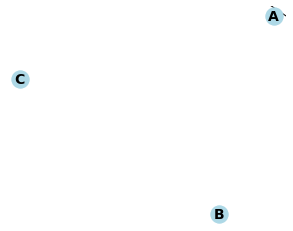

In [155]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'C')])

# Explicit figure + axes → avoids the broken _axstack logic
fig, ax = plt.subplots(figsize=(5, 4))
nx.draw(G, ax=ax, with_labels=True, node_color='lightblue', 
        node_size=300, font_weight='bold', font_size=14,edge_color='black')

plt.show()

In [156]:
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [158]:
pd.get_dummies(df,drop_first=True)

,post_id,likes,comments,shares,platform_Instagram,platform_Twitter,post_type_image,post_type_poll,post_type_text,post_type_video,...,post_time_9/27/2023 19:00,post_time_9/30/2023 10:30,post_day_Monday,post_day_Saturday,post_day_Sunday,post_day_Thursday,post_day_Tuesday,post_day_Wednesday,sentiment_score_neutral,sentiment_score_positive
0,1,2121,474,628,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,2,3660,432,694,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,3,4955,408,688,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,4,1183,90,187,False,True,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,5,3499,247,286,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,36,294,911,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
96,97,314,108,458,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
97,98,229,179,38,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
98,99,5000,500,204,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [159]:
import numpy as np

In [161]:
np.where(df['likes']>1000,'well','not well')

array(['well', 'well', 'well', 'well', 'well', 'not well', 'well', 'well',
       'not well', 'well', 'well', 'not well', 'not well', 'well',
       'not well', 'well', 'well', 'not well', 'well', 'not well',
       'not well', 'well', 'not well', 'well', 'not well', 'well', 'well',
       'well', 'not well', 'well', 'well', 'well', 'not well', 'well',
       'well', 'well', 'well', 'well', 'well', 'not well', 'not well',
       'well', 'well', 'well', 'well', 'well', 'well', 'well', 'not well',
       'well', 'well', 'not well', 'well', 'well', 'not well', 'well',
       'well', 'well', 'not well', 'well', 'well', 'well', 'not well',
       'not well', 'well', 'well', 'well', 'not well', 'not well', 'well',
       'well', 'well', 'well', 'well', 'well', 'well', 'well', 'well',
       'well', 'not well', 'well', 'well', 'well', 'well', 'well', 'well',
       'not well', 'well', 'well', 'well', 'well', 'well', 'not well',
       'well', 'well', 'not well', 'not well', 'not well', 'well'